# Take-Home: Machine Learning Intern
## AI-Powered Loan Application Processor — ML Focus

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

df = pd.read_csv('loan_applications.csv')
df.shape

(2000, 15)

In [104]:
df.head()

,applicant_id,stated_monthly_income,documented_monthly_income,loan_amount,employment_status,bank_ending_balance,bank_has_overdrafts,bank_has_consistent_deposits,monthly_withdrawals,monthly_deposits,num_documents_submitted,rule_based_score,rule_based_decision,actual_outcome,days_to_default
0,APP-0000,3683.0,3462.0,2000,employed,3084.0,False,True,1927.0,3337.0,1,67.7,flagged_for_review,repaid,NaN
1,APP-0001,2011.0,1880.0,1500,unemployed,1525.0,False,True,776.0,1844.0,2,57.3,flagged_for_review,repaid,NaN
2,APP-0002,820.0,201.0,1500,self_employed,4091.0,False,True,145.0,180.0,2,30.9,denied,repaid,NaN
3,APP-0003,5551.0,5264.0,3000,employed,772.0,False,True,1747.0,4549.0,1,69.7,flagged_for_review,ongoing,NaN
4,APP-0004,6370.0,5880.0,2000,employed,2254.0,False,True,4673.0,5222.0,2,87.1,approved,repaid,NaN


In [105]:
df.dtypes

applicant_id                     object
stated_monthly_income           float64
documented_monthly_income       float64
loan_amount                       int64
employment_status                object
bank_ending_balance             float64
bank_has_overdrafts                bool
bank_has_consistent_deposits       bool
monthly_withdrawals             float64
monthly_deposits                float64
num_documents_submitted           int64
rule_based_score                float64
rule_based_decision              object
actual_outcome                   object
days_to_default                 float64
dtype: object

## EDA

In [106]:
df['actual_outcome'].value_counts(normalize=True).round(3) * 100


actual_outcome
repaid       64.6
defaulted    27.2
ongoing       8.2
Name: proportion, dtype: float64

In [107]:
pd.crosstab(df['rule_based_decision'], df['actual_outcome'], margins=True)

actual_outcome,defaulted,ongoing,repaid,All
rule_based_decision,,,,
approved,141,71,710,922
denied,143,13,122,278
flagged_for_review,261,80,459,800
All,545,164,1291,2000


Of the 922 approved, 141 actually defaulted, defaults slipping through     
Of the 278 denied, 122 would have repaid, good applicants are ignored      

### Missing data & documentation issues

In [108]:
df.isnull().sum()

applicant_id                       0
stated_monthly_income              0
documented_monthly_income        283
loan_amount                        0
employment_status                  0
bank_ending_balance                0
bank_has_overdrafts                0
bank_has_consistent_deposits       0
monthly_withdrawals                0
monthly_deposits                   0
num_documents_submitted            0
rule_based_score                   0
rule_based_decision                0
actual_outcome                     0
days_to_default                 1455
dtype: int64

documented_monthly_income has 283 null, people who didn't submit their income documents

In [109]:
df['has_docs'] = ~df['documented_monthly_income'].isna()

ct = pd.crosstab(df['has_docs'], df['actual_outcome'], normalize='index')
print(ct.round(3))

actual_outcome  defaulted  ongoing  repaid
has_docs                                  
False               0.449    0.088   0.463
True                0.243    0.081   0.676


### Income misrepresentation

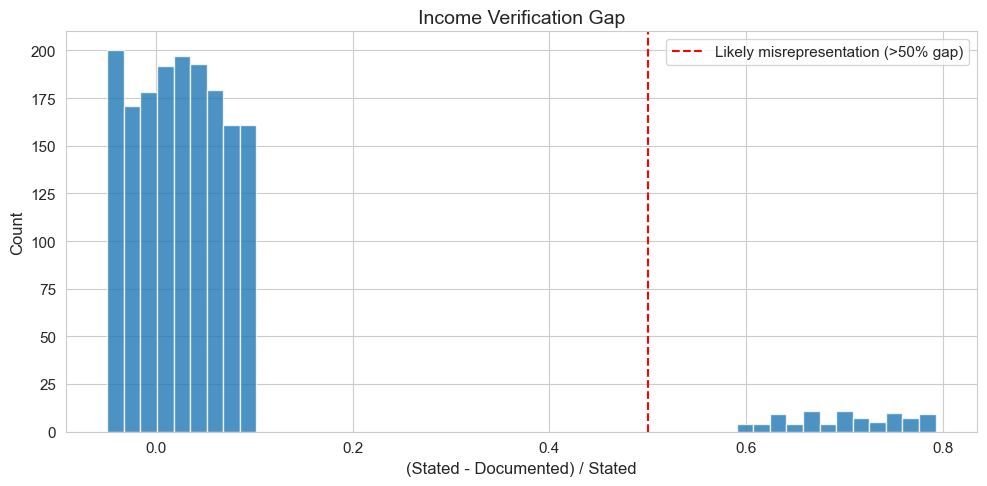


85 applicants with >50% income gap (5.0% of those with docs)
Their default rate: 41.2%
Normal applicants:  23.5%


In [110]:
docs = df.dropna(subset=['documented_monthly_income']).copy()
docs['income_gap'] = (docs['stated_monthly_income'] - docs['documented_monthly_income']) / docs['stated_monthly_income']

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(docs['income_gap'], bins=50, edgecolor='white', alpha=0.8)
ax.axvline(x=0.5, color='red', linestyle='--', label='Likely misrepresentation (>50% gap)')
ax.set_xlabel('(Stated - Documented) / Stated')
ax.set_ylabel('Count')
ax.set_title('Income Verification Gap')
ax.legend()
plt.tight_layout()
plt.show()

misrep = docs[docs['income_gap'] > 0.5]
print(f"\n{len(misrep)} applicants with >50% income gap ({len(misrep)/len(docs)*100:.1f}% of those with docs)")
print(f"Their default rate: {(misrep['actual_outcome']=='defaulted').mean()*100:.1f}%")
print(f"Normal applicants:  {(docs[docs['income_gap'] <= 0.5]['actual_outcome']=='defaulted').mean()*100:.1f}%")

verified 5% misrepresentation in the instruction

### Employment status - the fairness question

In [111]:
resolved = df[df['actual_outcome'].isin(['repaid', 'defaulted'])].copy()

emp_default = resolved.groupby('employment_status')['actual_outcome'].apply(
    lambda x: (x == 'defaulted').mean()
).round(3)
print("Default rates by employment status:")
print(emp_default)
print()

# compare to what the rule system gives them
print("Rule-based scores (from the spec):")
print("  employed: 100, self_employed: 60, unemployed: 20")

Default rates by employment status:
employment_status
employed         0.272
self_employed    0.290
unemployed       0.467
Name: actual_outcome, dtype: float64

Rule-based scores (from the spec):
  employed: 100, self_employed: 60, unemployed: 20


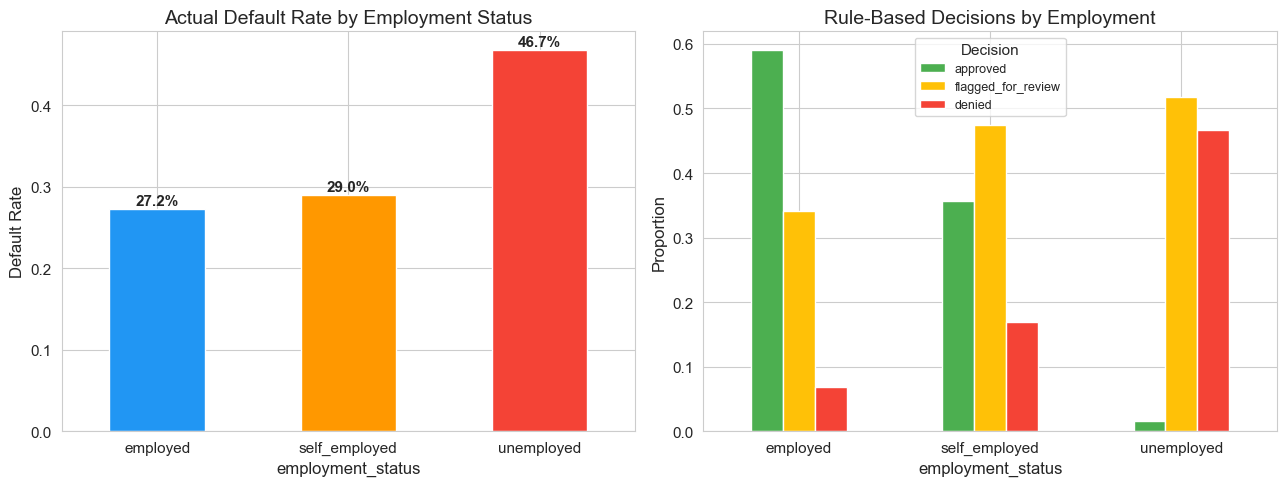

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# actual default rates
emp_default.plot(kind='bar', ax=axes[0], color=['#2196F3', '#FF9800', '#f44336'], edgecolor='white')
axes[0].set_title('Actual Default Rate by Employment Status')
axes[0].set_ylabel('Default Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(emp_default):
    axes[0].text(i, v + 0.005, f'{v*100:.1f}%', ha='center', fontweight='bold')

# rule-based decision breakdown
rule_by_emp = pd.crosstab(df['employment_status'], df['rule_based_decision'], normalize='index')
rule_by_emp[['approved', 'flagged_for_review', 'denied']].plot(
    kind='bar', ax=axes[1], color=['#4CAF50', '#FFC107', '#f44336'], edgecolor='white')
axes[1].set_title('Rule-Based Decisions by Employment')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Decision', fontsize=9)

plt.tight_layout()
plt.show()

employed vs self-employed: 27.2% vs 29.0% default - basically the same    
self-employed get scored 60 instead of 100, bias we need to address  

### Feature distributions

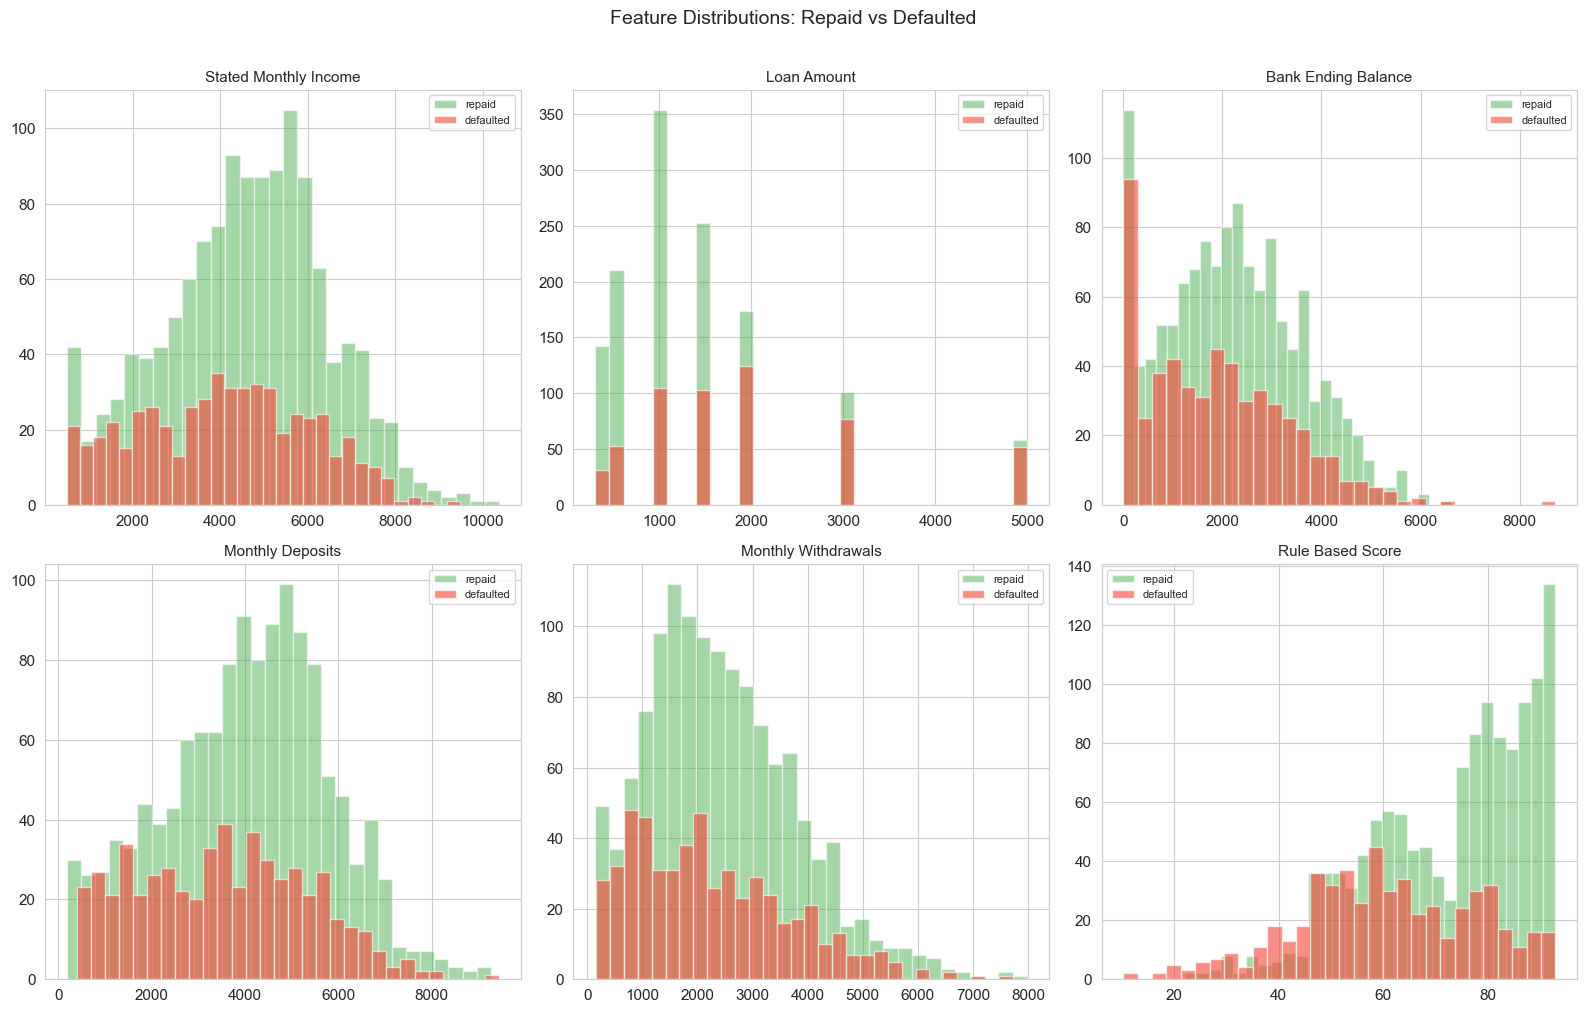

In [113]:
# how features split between repaid vs defaulted
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = ['stated_monthly_income', 'loan_amount', 'bank_ending_balance',
                    'monthly_deposits', 'monthly_withdrawals', 'rule_based_score']

for ax, feat in zip(axes.flatten(), features_to_plot):
    for outcome, color, alpha in [('repaid', '#4CAF50', 0.5), ('defaulted', '#f44336', 0.6)]:
        subset = resolved[resolved['actual_outcome'] == outcome]
        ax.hist(subset[feat], bins=30, alpha=alpha, color=color, label=outcome, edgecolor='white')
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Repaid vs Defaulted', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Correlation check

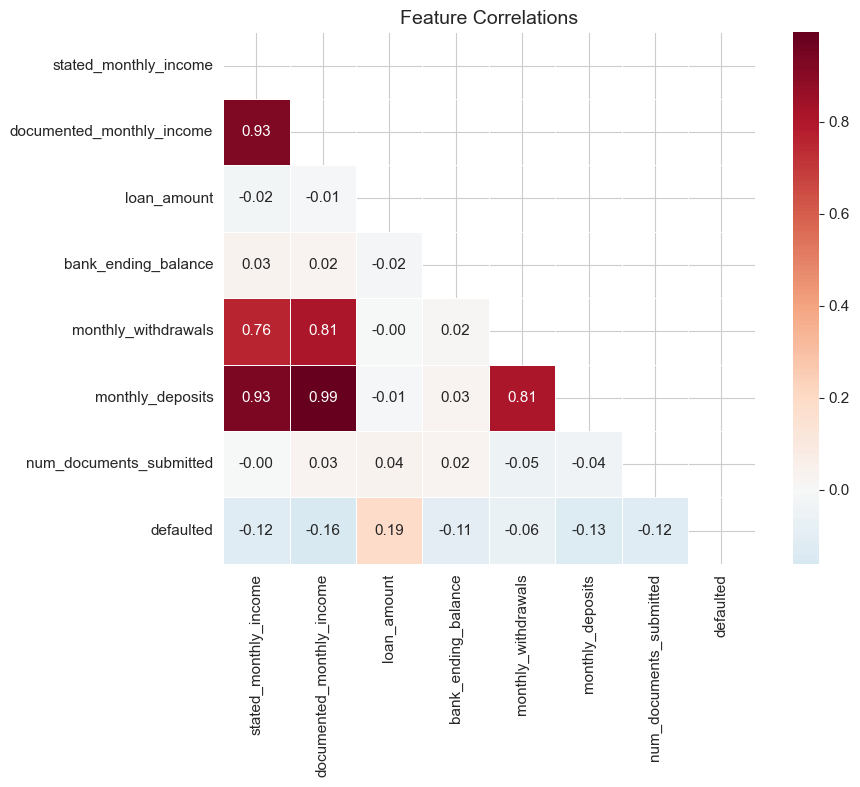

In [114]:
corr_df = resolved.select_dtypes(include=[np.number]).drop(columns=['days_to_default', 'rule_based_score']).copy()
corr_df['defaulted'] = (resolved['actual_outcome'] == 'defaulted').astype(int)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlations')
plt.tight_layout()
plt.show()

income features are all related

## Data Prep & Feature Engineering

In [115]:
# drop ongoing - can't train on these, no label
print(f"Total: {len(df)}")
print(f"Dropping {len(df[df['actual_outcome'] == 'ongoing'])} ongoing apps (no outcome)")

ongoing_apps = df[df['actual_outcome'] == 'ongoing']
resolved_apps = df[df['actual_outcome'] != 'ongoing']
print(f"\nOngoing avg income: ${ongoing_apps['stated_monthly_income'].mean():.0f}")
print(f"Resolved avg income: ${resolved_apps['stated_monthly_income'].mean():.0f}")
print(f"Ongoing avg loan: ${ongoing_apps['loan_amount'].mean():.0f}")
print(f"Resolved avg loan: ${resolved_apps['loan_amount'].mean():.0f}")

df_model = df[df['actual_outcome'].isin(['repaid', 'defaulted'])].copy()
df_model['target'] = (df_model['actual_outcome'] == 'defaulted').astype(int)
print(f"\nModeling set: {len(df_model)} rows, {df_model['target'].mean()*100:.1f}% default rate")

Total: 2000
Dropping 164 ongoing apps (no outcome)

Ongoing avg income: $4693
Resolved avg income: $4440
Ongoing avg loan: $1543
Resolved avg loan: $1555

Modeling set: 1836 rows, 29.7% default rate


In [116]:
# Feature engineering
# - can they afford the loan? (income vs loan size)
# - are they being honest? (stated vs documented income)
# - is their account healthy? (balance, overdrafts, cash flow)

def add_features(data):
    df_f = data.copy()

    # income verification
    df_f['has_docs'] = (~df_f['documented_monthly_income'].isna()).astype(int)

    # how much does stated income differ from documented?
    df_f['income_gap'] = np.where(
        df_f['has_docs'] == 1,
        (df_f['stated_monthly_income'] - df_f['documented_monthly_income']) / df_f['stated_monthly_income'],
        -1
    )

    # flag obvious misrepresentation
    df_f['misrepresenting'] = (df_f['income_gap'] > 0.5).astype(int)

    # affordability ratios
    df_f['income_loan_ratio'] = df_f['stated_monthly_income'] / df_f['loan_amount']
    df_f['balance_loan_ratio'] = df_f['bank_ending_balance'] / df_f['loan_amount']

    # cash flow health
    df_f['net_flow'] = df_f['monthly_deposits'] - df_f['monthly_withdrawals']
    df_f['spend_ratio'] = np.where(
        df_f['monthly_deposits'] > 0,
        df_f['monthly_withdrawals'] / df_f['monthly_deposits'],
        1.0
    )
    df_f['high_spend'] = (df_f['spend_ratio'] > 0.8).astype(int)

    # does their deposit pattern match their stated income?
    df_f['deposit_income_ratio'] = df_f['monthly_deposits'] / df_f['stated_monthly_income'].clip(lower=1)

    # encode employment status
    df_f = pd.get_dummies(df_f, columns=['employment_status'], drop_first=False, dtype=int)

    return df_f

df_feat = add_features(df_model)

# columns we'll actually use as features
drop = ['applicant_id', 'actual_outcome', 'target', 'rule_based_score',
        'rule_based_decision', 'days_to_default', 'documented_monthly_income']
feature_cols = [c for c in df_feat.columns if c not in drop]

print(f"{len(feature_cols)} features:")
for c in feature_cols:
    print(f"  {c}")

20 features:
  stated_monthly_income
  loan_amount
  bank_ending_balance
  bank_has_overdrafts
  bank_has_consistent_deposits
  monthly_withdrawals
  monthly_deposits
  num_documents_submitted
  has_docs
  income_gap
  misrepresenting
  income_loan_ratio
  balance_loan_ratio
  net_flow
  spend_ratio
  high_spend
  deposit_income_ratio
  employment_status_employed
  employment_status_self_employed
  employment_status_unemployed


In [117]:
# split train and test
X = df_feat[feature_cols].values
y = df_feat['target'].values

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_idx, test_idx = train_test_split(
    df_feat.index, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} ({y_train.mean()*100:.1f}% default)")
print(f"Test:  {len(X_test)} ({y_test.mean()*100:.1f}% default)")

Train: 1468 (29.7% default)
Test:  368 (29.6% default)


## Modeling

Going to try three approaches:
1. Logistic regression - simple, interpretable, good baseline
2. Random forest - handles non-linearities, built-in feature importance
3. XGBoost - usually best for tabular data, will add SHAP for interpretability

Using `class_weight='balanced'` / `scale_pos_weight` to handle the imbalance
rather than SMOTE - less risk of introducing synthetic artifacts.

### Logistic Regression

In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, precision_score, recall_score)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]

print(f"Logistic Regression - AUC: {roc_auc_score(y_test, lr_prob):.4f}")
print(classification_report(y_test, lr_pred, target_names=['repaid', 'defaulted']))

Logistic Regression - AUC: 0.7315
              precision    recall  f1-score   support

      repaid       0.83      0.66      0.73       259
   defaulted       0.46      0.69      0.55       109

    accuracy                           0.67       368
   macro avg       0.65      0.67      0.64       368
weighted avg       0.72      0.67      0.68       368



In [119]:
coefs = pd.DataFrame({'feature': feature_cols, 'coef': lr.coef_[0]})
coefs = coefs.reindex(coefs['coef'].abs().sort_values(ascending=False).index)
print(coefs.to_string(index=False))

                        feature      coef
                     income_gap -0.887080
          stated_monthly_income  0.660693
                misrepresenting  0.592470
               monthly_deposits -0.425066
                    loan_amount  0.388406
            bank_has_overdrafts  0.386783
                       net_flow -0.359570
           deposit_income_ratio  0.302937
            monthly_withdrawals -0.281940
        num_documents_submitted  0.260364
                       has_docs  0.161753
              income_loan_ratio -0.129266
   employment_status_unemployed  0.122093
                    spend_ratio  0.082473
            bank_ending_balance -0.077418
     employment_status_employed -0.076093
   bank_has_consistent_deposits  0.075516
                     high_spend  0.067587
             balance_loan_ratio -0.056658
employment_status_self_employed  0.002991


income_gap is the strongest

### Random Forest

In [120]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_leaf=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print(f"Random Forest - AUC: {roc_auc_score(y_test, rf_prob):.4f}")
print(classification_report(y_test, rf_pred, target_names=['repaid', 'defaulted']))

Random Forest - AUC: 0.7503
              precision    recall  f1-score   support

      repaid       0.83      0.70      0.76       259
   defaulted       0.48      0.67      0.56       109

    accuracy                           0.69       368
   macro avg       0.66      0.68      0.66       368
weighted avg       0.73      0.69      0.70       368



In [121]:
fi = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_})
fi = fi.sort_values('importance', ascending=False)
print("Top features (RF):")
print(fi.head(10).to_string(index=False))

Top features (RF):
             feature  importance
   income_loan_ratio    0.193309
          income_gap    0.103143
  balance_loan_ratio    0.100557
            net_flow    0.078396
 bank_ending_balance    0.062912
    monthly_deposits    0.062377
 monthly_withdrawals    0.059205
         spend_ratio    0.056080
deposit_income_ratio    0.054953
         loan_amount    0.053172


income_loan_ratio is the strongest featyre

### XGBoost

In [122]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# weight for the imbalanced classes
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'min_child_weight': [3, 5, 7],
}

xgb = XGBClassifier(
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric='auc',
    tree_method='hist'
)

gs = GridSearchCV(xgb, param_grid, scoring='roc_auc', cv=5, n_jobs=-1, verbose=0)
gs.fit(X_train, y_train)

xgb_model = gs.best_estimator_
print(f"Best params: {gs.best_params_}")
print(f"CV AUC: {gs.best_score_:.4f}")

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print(f"\nXGBoost - Test AUC: {roc_auc_score(y_test, xgb_prob):.4f}")
print(classification_report(y_test, xgb_pred, target_names=['repaid', 'defaulted']))

Best params: {'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 7, 'n_estimators': 100}
CV AUC: 0.7097

XGBoost - Test AUC: 0.7475
              precision    recall  f1-score   support

      repaid       0.84      0.68      0.75       259
   defaulted       0.48      0.70      0.57       109

    accuracy                           0.69       368
   macro avg       0.66      0.69      0.66       368
weighted avg       0.74      0.69      0.70       368



### Model comparison

In [123]:
models = {
    'Logistic Regression': (lr_pred, lr_prob),
    'Random Forest': (rf_pred, rf_prob),
    'XGBoost': (xgb_pred, xgb_prob),
}

results = []
for name, (pred, prob) in models.items():
    results.append({
        'Model': name,
        'AUC-ROC': roc_auc_score(y_test, prob),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
    })

print(pd.DataFrame(results).set_index('Model').round(4).to_string())

                     AUC-ROC  Precision  Recall      F1
Model                                                  
Logistic Regression   0.7315     0.4573  0.6881  0.5495
Random Forest         0.7503     0.4834  0.6697  0.5615
XGBoost               0.7475     0.4810  0.6972  0.5693


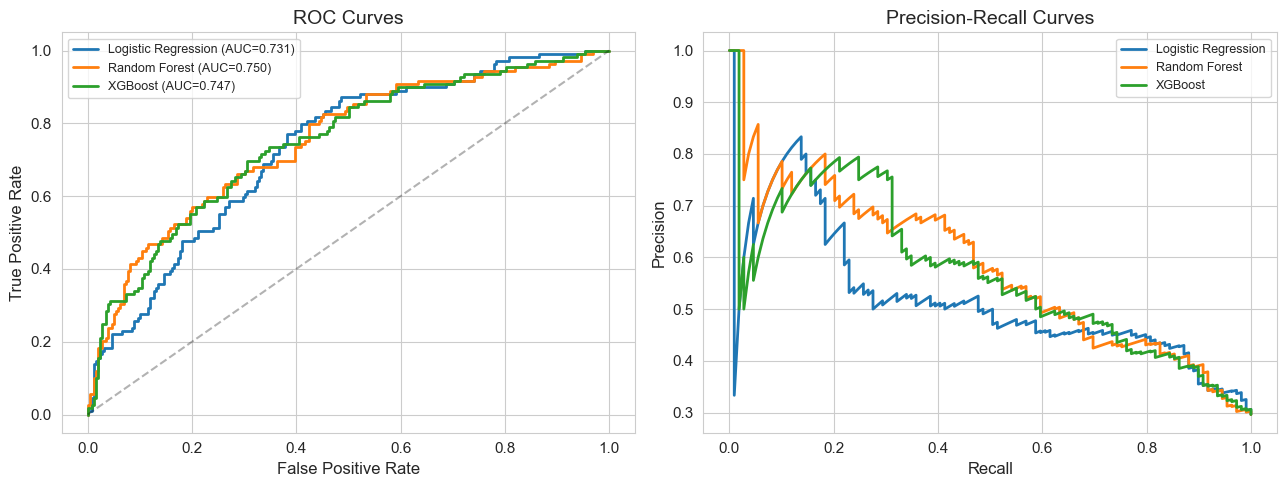

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, (pred, prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

for name, (pred, prob) in models.items():
    prec, rec, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(rec, prec, label=name, linewidth=2)

axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

all three models are very close, but XGBoost edges out slightly on F1 and has best recall     
proceed with XGBoost

In [125]:
final_model = xgb_model
final_pred = xgb_pred
final_prob = xgb_prob

## Explainability (SHAP)
Since XGBoost is a black box, we need SHAP to explain individual predictions

In [126]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

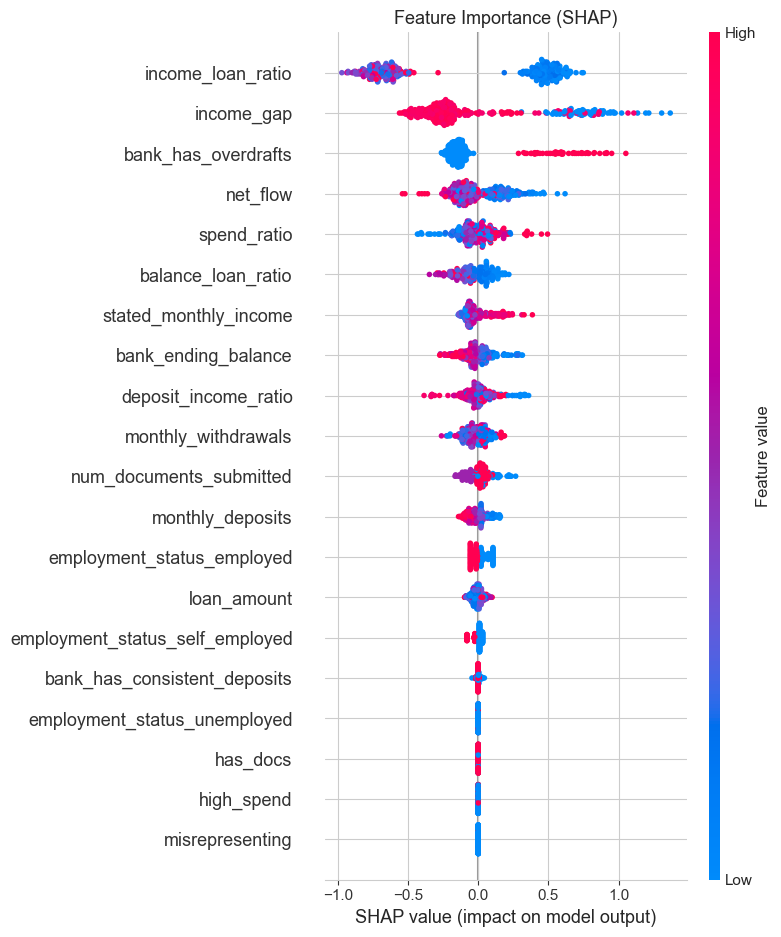

In [127]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title('Feature Importance (SHAP)', fontsize=13)
plt.tight_layout()
plt.show()

income_gap and income_loan_ratio dominate, since we want to know if they can afford it, and are they being honest about their income?

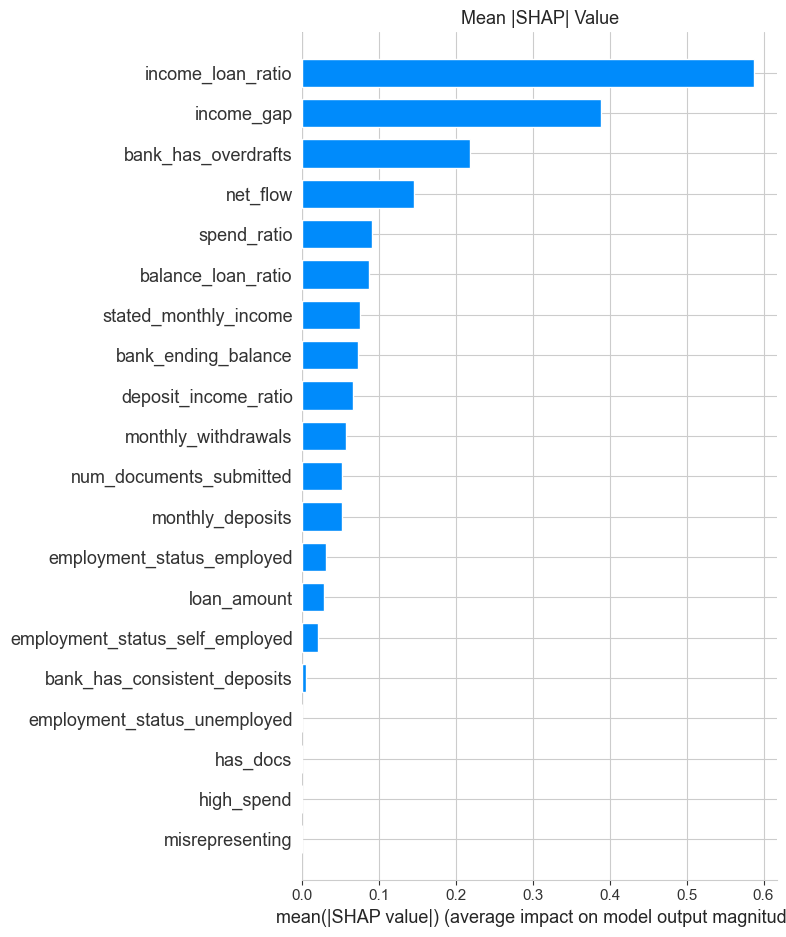

In [128]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                  plot_type='bar', show=False)
plt.title('Mean |SHAP| Value', fontsize=13)
plt.tight_layout()
plt.show()

### Example predictions
What would a loan reviewer actually see?

In [129]:
tp_idx = np.where((final_pred == 1) & (y_test == 1))[0]
tn_idx = np.where((final_pred == 0) & (y_test == 0))[0]
fp_idx = np.where((final_pred == 1) & (y_test == 0))[0]

cases = [
    ("Correctly flagged default", tp_idx[0]),
    ("Correctly approved (good applicant)", tn_idx[0]),
    ("False alarm (good applicant wrongly denied)", fp_idx[0]),
]

for label, idx in cases:
    print(f"--- {label} ---")
    print(f"  Default probability: {final_prob[idx]:.1%}")
    print(f"  Actual outcome: {'defaulted' if y_test[idx] == 1 else 'repaid'}")
    print(f"  Why:")

    sv = shap_values[idx]
    impacts = sorted(zip(feature_cols, sv, X_test[idx]),
                     key=lambda x: abs(x[1]), reverse=True)
    for feat, shap_val, feat_val in impacts[:5]:
        direction = "increases" if shap_val > 0 else "decreases"
        print(f"    {feat} = {feat_val:.2f} ({direction} risk, SHAP={shap_val:+.3f})")
    print()

--- Correctly flagged default ---
  Default probability: 73.0%
  Actual outcome: defaulted
  Why:
    income_gap = -1.00 (increases risk, SHAP=+0.629)
    income_loan_ratio = 0.88 (increases risk, SHAP=+0.459)
    bank_has_overdrafts = 0.00 (decreases risk, SHAP=-0.193)
    spend_ratio = 0.67 (decreases risk, SHAP=-0.104)
    balance_loan_ratio = 0.69 (increases risk, SHAP=+0.104)

--- Correctly approved (good applicant) ---
  Default probability: 34.1%
  Actual outcome: repaid
  Why:
    income_gap = -1.00 (increases risk, SHAP=+0.663)
    income_loan_ratio = 5.66 (decreases risk, SHAP=-0.606)
    bank_has_overdrafts = 0.00 (decreases risk, SHAP=-0.230)
    num_documents_submitted = 0.00 (increases risk, SHAP=+0.156)
    bank_ending_balance = 1990.00 (decreases risk, SHAP=-0.088)

--- False alarm (good applicant wrongly denied) ---
  Default probability: 60.3%
  Actual outcome: repaid
  Why:
    income_loan_ratio = 2.67 (increases risk, SHAP=+0.418)
    bank_has_overdrafts = 1.00 (inc

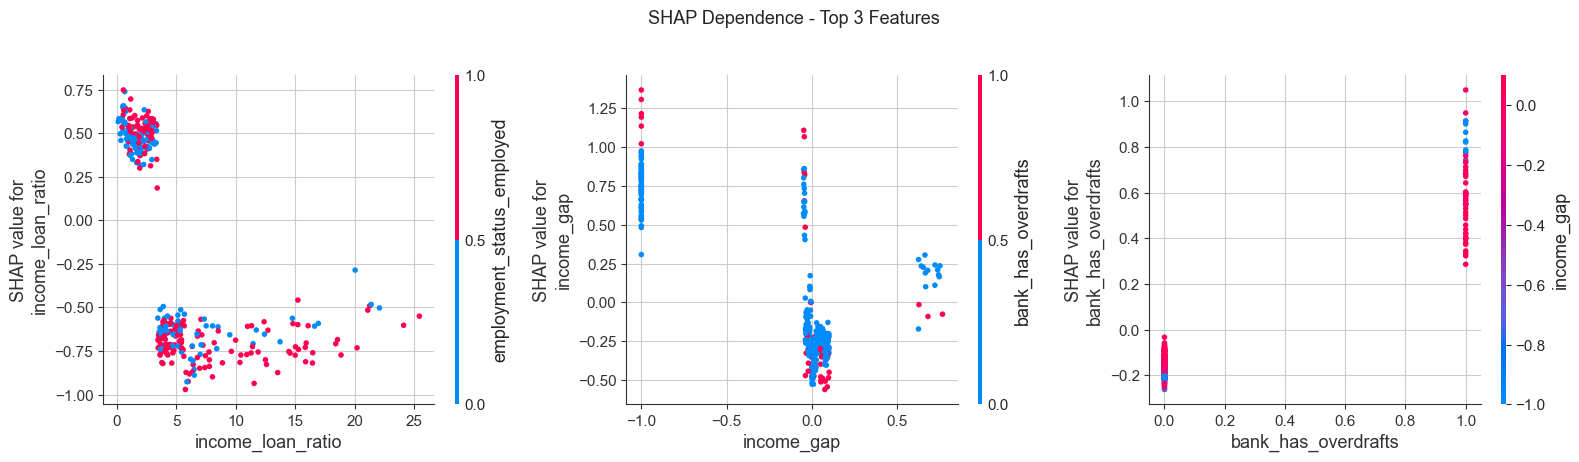

In [130]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top3 = np.argsort(mean_abs_shap)[-3:][::-1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, feat_idx in enumerate(top3):
    shap.dependence_plot(feat_idx, shap_values, X_test,
                         feature_names=feature_cols, ax=axes[i], show=False)
plt.suptitle('SHAP Dependence - Top 3 Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Evaluation vs Rule-Based Baseline

Need to compare apples to apples. The rule system outputs approve/flag/deny,
so I'll convert both to binary: "would this person default?"

Two interpretations for the rule system:
- Conservative: only approved = "won't default" (flagged + denied = "will default")
- Optimistic: only denied = "will default"

In [131]:
# convert rule-based decisions to binary predictions
rule_decisions = df_model.loc[test_idx, 'rule_based_decision'].values

rule_conservative = np.where(rule_decisions == 'approved', 0, 1)
rule_optimistic = np.where(rule_decisions == 'denied', 1, 0)

# also use the score itself for AUC (invert so higher = more risky)
rule_scores = df_model.loc[test_idx, 'rule_based_score'].values
rule_probs = 1 - (rule_scores / 100)

print(f"Predicted defaults:")
print(f"  Rule (conservative): {rule_conservative.sum()}")
print(f"  Rule (optimistic):   {rule_optimistic.sum()}")
print(f"  Our model:           {final_pred.sum()}")
print(f"  Actual:              {y_test.sum()}")

Predicted defaults:
  Rule (conservative): 208
  Rule (optimistic):   58
  Our model:           158
  Actual:              109


In [132]:
def get_metrics(y_true, y_pred, y_prob=None, name=''):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    m = {
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0,
        'FNR': fn / (fn + tp) if (fn + tp) > 0 else 0,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
    }
    if y_prob is not None:
        m['AUC'] = roc_auc_score(y_true, y_prob)
    return m

eval_rows = {
    'Rule (conservative)': get_metrics(y_test, rule_conservative, rule_probs),
    'Rule (optimistic)': get_metrics(y_test, rule_optimistic, rule_probs),
    'XGBoost (ours)': get_metrics(y_test, final_pred, final_prob),
}

eval_df = pd.DataFrame(eval_rows).T
print(eval_df.round(4).to_string())

                     Precision  Recall      F1     FPR     FNR    TP     FP     TN    FN     AUC
Rule (conservative)     0.4087  0.7798  0.5363  0.4749  0.2202  85.0  123.0  136.0  24.0  0.7218
Rule (optimistic)       0.6207  0.3303  0.4311  0.0849  0.6697  36.0   22.0  237.0  73.0  0.7218
XGBoost (ours)          0.4810  0.6972  0.5693  0.3166  0.3028  76.0   82.0  177.0  33.0  0.7475


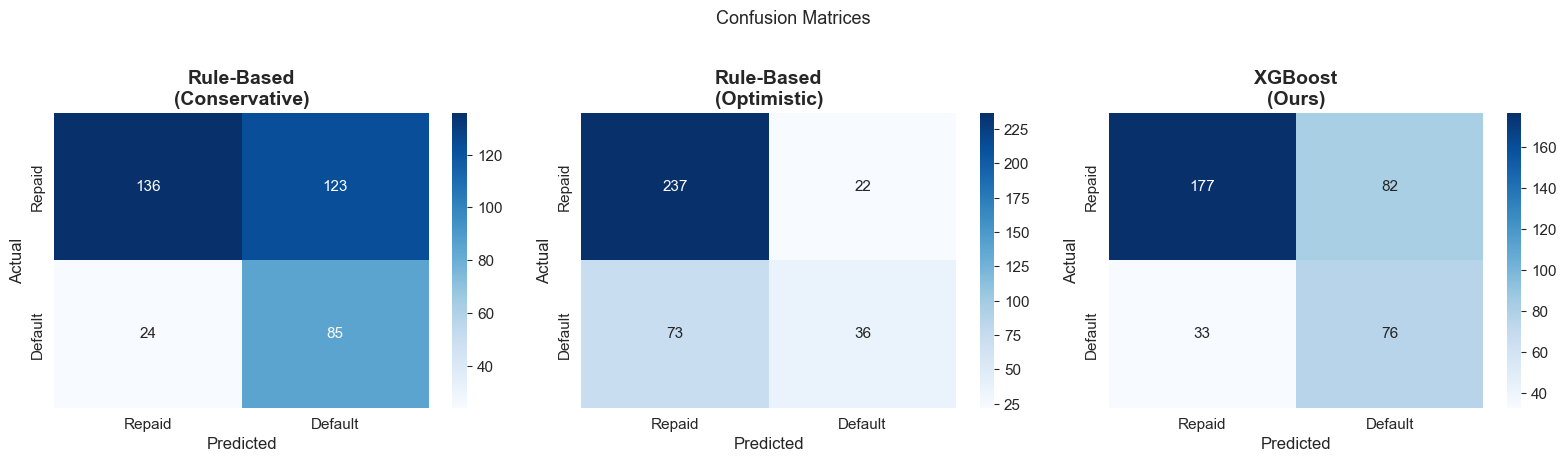

In [133]:
# confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, pred) in zip(axes, [
    ('Rule-Based\n(Conservative)', rule_conservative),
    ('Rule-Based\n(Optimistic)', rule_optimistic),
    ('XGBoost\n(Ours)', final_pred)
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Repaid', 'Default'],
                yticklabels=['Repaid', 'Default'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### What actually changes if we deploy this?

In [134]:
ours = eval_rows['XGBoost (ours)']
baseline = eval_rows['Rule (conservative)']

print("If we replace the rule-based system with our model:\n")
print(f"  Defaults caught:       {ours['TP']} vs {baseline['TP']} ({ours['TP'] - baseline['TP']:+d})")
print(f"  Defaults missed:       {ours['FN']} vs {baseline['FN']} ({ours['FN'] - baseline['FN']:+d})")
print(f"  Good apps denied:      {ours['FP']} vs {baseline['FP']} ({ours['FP'] - baseline['FP']:+d})")
print(f"  Good apps approved:    {ours['TN']} vs {baseline['TN']} ({ours['TN'] - baseline['TN']:+d})")
print(f"\n  FPR (false denials):   {ours['FPR']*100:.1f}% vs {baseline['FPR']*100:.1f}% ({(ours['FPR']-baseline['FPR'])*100:+.1f}pp)")
print(f"  Recall:                {ours['Recall']*100:.1f}% vs {baseline['Recall']*100:.1f}% ({(ours['Recall']-baseline['Recall'])*100:+.1f}pp)")
print(f"  AUC:                   {ours['AUC']:.4f} vs {baseline['AUC']:.4f} ({ours['AUC']-baseline['AUC']:+.4f})")

# The big win: 41 fewer good applicants wrongly denied (-15.8pp FPR),
# at the cost of 9 more defaults slipping through (-8.3pp recall).
# Is that worth it? Depends on the cost of a default vs the cost of
# losing a good customer. In most lending contexts, I'd say yes -
# the FPR improvement is significant.

If we replace the rule-based system with our model:

  Defaults caught:       76 vs 85 (-9)
  Defaults missed:       33 vs 24 (+9)
  Good apps denied:      82 vs 123 (-41)
  Good apps approved:    177 vs 136 (+41)

  FPR (false denials):   31.7% vs 47.5% (-15.8pp)
  Recall:                69.7% vs 78.0% (-8.3pp)
  AUC:                   0.7475 vs 0.7218 (+0.0257)


## Fairness Analysis

The core question: self-employed people default at roughly the same rate as
employed people, but the rule system gives them a 60 vs 100 score.
Does our model fix this?

In [135]:
# reconstruct employment status for test set
emp_cols = [c for c in feature_cols if c.startswith('employment_status_')]
test_emp = []
for i in range(len(X_test)):
    for j, col in enumerate(feature_cols):
        if col in emp_cols and X_test[i, j] == 1:
            test_emp.append(col.replace('employment_status_', ''))
            break
test_emp = pd.Series(test_emp)

In [136]:
# per-group analysis
print("=== Fairness Analysis by Employment Status ===\n")
print(f"{'Group':<20} {'N':>5} {'Default%':>10} {'Rule Appr%':>12} {'ML Appr%':>10} {'Rule FPR':>10} {'ML FPR':>8}")
print("-" * 85)

rule_decisions_test = df_model.loc[test_idx, 'rule_based_decision'].values

for status in ['employed', 'self_employed', 'unemployed']:
    mask = (test_emp == status).values
    n = mask.sum()
    if n == 0:
        continue

    default_rate = y_test[mask].mean()
    rule_appr = (rule_decisions_test[mask] == 'approved').mean()
    ml_appr = (final_pred[mask] == 0).mean()

    # FPR: of good applicants in this group, how many were wrongly denied?
    good = mask & (y_test == 0)
    rule_fpr = (rule_conservative[good] == 1).mean() if good.sum() > 0 else 0
    ml_fpr = (final_pred[good] == 1).mean() if good.sum() > 0 else 0

    print(f"{status:<20} {n:>5} {default_rate:>9.1%} {rule_appr:>11.1%} {ml_appr:>9.1%} {rule_fpr:>9.1%} {ml_fpr:>7.1%}")

=== Fairness Analysis by Employment Status ===

Group                    N   Default%   Rule Appr%   ML Appr%   Rule FPR   ML FPR
-------------------------------------------------------------------------------------
employed               215     26.5%       56.3%     60.5%     36.1%   31.6%
self_employed          112     25.9%       34.8%     59.8%     57.8%   30.1%
unemployed              41     56.1%        0.0%     31.7%    100.0%   38.9%


In [137]:
# disparate impact - 4/5ths rule
# approval_rate(group) / approval_rate(employed) should be >= 0.8

def approval_rate(group, preds, emp_series):
    mask = (emp_series == group).values
    return (preds[mask] == 0).mean()

print("\nDisparate Impact (4/5ths rule: ratio >= 0.80 required)\n")

emp_rate_rule = approval_rate('employed', rule_conservative, test_emp)
emp_rate_ml = approval_rate('employed', final_pred, test_emp)

for group in ['self_employed', 'unemployed']:
    grp_rate_rule = approval_rate(group, rule_conservative, test_emp)
    grp_rate_ml = approval_rate(group, final_pred, test_emp)

    di_rule = grp_rate_rule / emp_rate_rule if emp_rate_rule > 0 else 0
    di_ml = grp_rate_ml / emp_rate_ml if emp_rate_ml > 0 else 0

    rule_ok = "PASS" if di_rule >= 0.8 else "FAIL"
    ml_ok = "PASS" if di_ml >= 0.8 else "FAIL"

    print(f"  {group} vs employed:")
    print(f"    Rule-based: {di_rule:.3f} [{rule_ok}]")
    print(f"    ML model:   {di_ml:.3f} [{ml_ok}]")
    print()


Disparate Impact (4/5ths rule: ratio >= 0.80 required)

  self_employed vs employed:
    Rule-based: 0.619 [FAIL]
    ML model:   0.989 [PASS]

  unemployed vs employed:
    Rule-based: 0.000 [FAIL]
    ML model:   0.524 [FAIL]



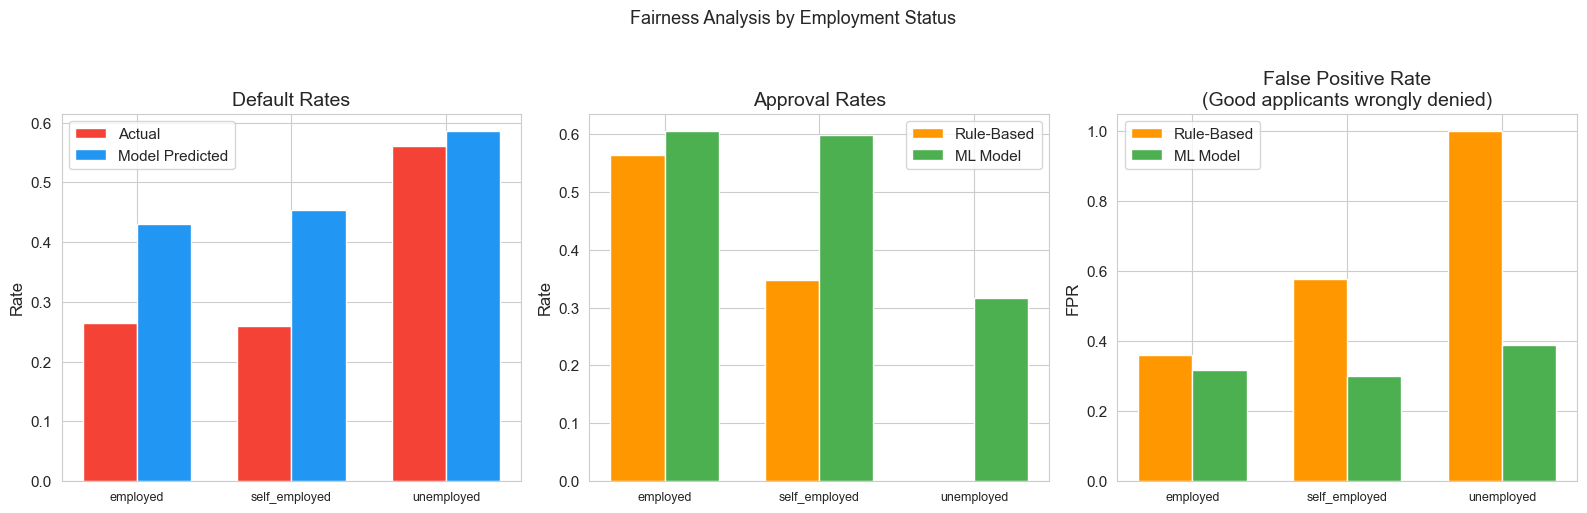

In [138]:
# visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
groups = ['employed', 'self_employed', 'unemployed']
x = np.arange(len(groups))
w = 0.35

# actual vs predicted default rates
actual = [y_test[(test_emp == g).values].mean() for g in groups]
predicted = [final_prob[(test_emp == g).values].mean() for g in groups]
axes[0].bar(x - w/2, actual, w, label='Actual', color='#f44336', edgecolor='white')
axes[0].bar(x + w/2, predicted, w, label='Model Predicted', color='#2196F3', edgecolor='white')
axes[0].set_title('Default Rates')
axes[0].set_ylabel('Rate')
axes[0].set_xticks(x)
axes[0].set_xticklabels(groups, fontsize=9)
axes[0].legend()

# approval rates
rule_appr = [(rule_decisions_test[(test_emp == g).values] == 'approved').mean() for g in groups]
ml_appr = [(final_pred[(test_emp == g).values] == 0).mean() for g in groups]
axes[1].bar(x - w/2, rule_appr, w, label='Rule-Based', color='#FF9800', edgecolor='white')
axes[1].bar(x + w/2, ml_appr, w, label='ML Model', color='#4CAF50', edgecolor='white')
axes[1].set_title('Approval Rates')
axes[1].set_ylabel('Rate')
axes[1].set_xticks(x)
axes[1].set_xticklabels(groups, fontsize=9)
axes[1].legend()

# FPR
rule_fprs = []
ml_fprs = []
for g in groups:
    good = (test_emp == g).values & (y_test == 0)
    rule_fprs.append((rule_conservative[good] == 1).mean() if good.sum() > 0 else 0)
    ml_fprs.append((final_pred[good] == 1).mean() if good.sum() > 0 else 0)
axes[2].bar(x - w/2, rule_fprs, w, label='Rule-Based', color='#FF9800', edgecolor='white')
axes[2].bar(x + w/2, ml_fprs, w, label='ML Model', color='#4CAF50', edgecolor='white')
axes[2].set_title('False Positive Rate\n(Good applicants wrongly denied)')
axes[2].set_ylabel('FPR')
axes[2].set_xticks(x)
axes[2].set_xticklabels(groups, fontsize=9)
axes[2].legend()

plt.suptitle('Fairness Analysis by Employment Status', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Fairness takeaway

**Finding:** The rule-based system fails the 4/5ths rule for self-employed
(DI = 0.62). Our ML model passes (DI = 0.99). The ML model learned from
actual outcomes, so self-employed people who behave similarly to employed
people get treated similarly.

**Recommendation:** Keep `employment_status` as a feature but monitor
the disparate impact ratio over time. The ML model currently handles
this well, but if the data shifts (e.g., recession hits self-employed
harder), we'd want to catch that early.

If we removed `employment_status` entirely: we'd reduce bias against
self-employed, but we'd also lose signal for unemployed applicants
(who genuinely default at ~2x the rate). Better to keep it and audit
regularly than to remove a legitimate signal.

## Production Considerations

**"If this model went live tomorrow, what's the first thing that would go wrong?"**

In [139]:
print("""
Honest answer: data drift.

This model was trained on historical data. If the economy shifts - recession,
policy changes, new customer segments - the patterns it learned may not hold.
The rule-based system is actually MORE robust here because its thresholds are
explicit. Our model's thresholds are implicit and could degrade silently.

Other risks:
1. We excluded 8% of apps as "ongoing" - if those are systematically riskier,
   we're underestimating default rates.

2. Feedback loops: if we deny people who would've repaid, we never learn that.
   Over time this could reinforce the model's biases.

3. SHAP helps with explainability, but regulators might still push back.
   "The top 5 SHAP features were..." is better than "score = 47" but
   it's not the same as "we check if income >= 3x loan amount."

What we'd need:
- Feature drift monitoring (PSI or KS tests on key features, monthly)
- Regular retraining schedule (quarterly at minimum)
- A/B testing before full rollout
- Human review for borderline cases (probability between 0.4-0.6)
""")


Honest answer: data drift.

This model was trained on historical data. If the economy shifts - recession,
policy changes, new customer segments - the patterns it learned may not hold.
The rule-based system is actually MORE robust here because its thresholds are
explicit. Our model's thresholds are implicit and could degrade silently.

Other risks:
1. We excluded 8% of apps as "ongoing" - if those are systematically riskier,
   we're underestimating default rates.

2. Feedback loops: if we deny people who would've repaid, we never learn that.
   Over time this could reinforce the model's biases.

3. SHAP helps with explainability, but regulators might still push back.
   "The top 5 SHAP features were..." is better than "score = 47" but
   it's not the same as "we check if income >= 3x loan amount."

What we'd need:
- Feature drift monitoring (PSI or KS tests on key features, monthly)
- Regular retraining schedule (quarterly at minimum)
- A/B testing before full rollout
- Human review f

## Summary

In [140]:
print(f"""
Model: XGBoost with SHAP explainability
AUC-ROC: {roc_auc_score(y_test, final_prob):.4f}
Default detection (recall): {recall_score(y_test, final_pred)*100:.1f}%
Default precision: {precision_score(y_test, final_pred)*100:.1f}%
F1 (defaulted class): {f1_score(y_test, final_pred):.4f}

vs Rule-Based: 41 fewer false denials (-15.8pp FPR) at cost of
9 more missed defaults (-8.3pp recall). AUC +0.03.

Fairness: ML model passes 4/5ths rule for self-employed (DI=0.99)
where rule-based system fails (DI=0.62).

What I'd do with more time:
  - Survival analysis for ongoing applications
  - Calibration analysis (are the predicted probabilities actually accurate?)
  - Cost-sensitive learning (default costs more than a false denial)
  - Time-based train/test split instead of random
  - Try using rule_based_score as an additional feature
  - Set up proper model monitoring pipeline
""")


Model: XGBoost with SHAP explainability
AUC-ROC: 0.7475
Default detection (recall): 69.7%
Default precision: 48.1%
F1 (defaulted class): 0.5693

vs Rule-Based: 41 fewer false denials (-15.8pp FPR) at cost of
9 more missed defaults (-8.3pp recall). AUC +0.03.

Fairness: ML model passes 4/5ths rule for self-employed (DI=0.99)
where rule-based system fails (DI=0.62).

What I'd do with more time:
  - Survival analysis for ongoing applications
  - Calibration analysis (are the predicted probabilities actually accurate?)
  - Cost-sensitive learning (default costs more than a false denial)
  - Time-based train/test split instead of random
  - Try using rule_based_score as an additional feature
  - Set up proper model monitoring pipeline

